## Notebook 6 - Hierarchical Reconciliation (Store-Level Scaling)

This notebook explores hierarchical reconciliation to ensure that store-level forecasts align with aggregate sales.

Scaling factors are computed to adjust predictions, but results show minimal improvement, indicating the base ensemble model is already well-calibrated.

In [1]:
#Imports
import pandas as pd
import numpy as np

In [2]:
# 1. LOAD FULL PREDICTIONS (TRAIN + TEST)

df = pd.read_csv("final_predictions_full.csv", parse_dates=['Date'])
print("Shape:", df.shape)
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Unique stores: {df['Store'].nunique()}")

Shape: (844338, 4)
Date range: 2013-01-01 00:00:00 → 2015-07-31 00:00:00
Unique stores: 1115


In [3]:
# 2. ADD STORE TYPE

store_info = pd.read_csv("store.csv")[['Store','StoreType']]
df = df.merge(store_info, on='Store', how='left')
print("Missing StoreType:", df['StoreType'].isnull().sum())


Missing StoreType: 0


In [4]:
# 3. DEFINE TRAIN / TEST SPLIT

cutoff_date = "2015-06-01"
train_mask  = df['Date'] < cutoff_date
test_mask   = df['Date'] >= cutoff_date
print(f"Training rows : {train_mask.sum():,}")
print(f"Test rows     : {test_mask.sum():,}")


Training rows : 785,727
Test rows     : 58,611


In [5]:
# 4. RMSPE HELPER

def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true > 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


In [6]:
# CREATE DAILY TOTALS (FOR ANALYSIS ONLY)

daily_totals = df.groupby('Date').agg({
    'Sales': 'sum',
    'pred': 'sum'
})

daily_totals['scale'] = daily_totals['Sales'] / daily_totals['pred']
daily_totals['scale'] = daily_totals['scale'].replace([np.inf, -np.inf], 1).fillna(1)

In [7]:
# 5. STORE-LEVEL SCALING (using training period only)

store_actual_train = df[train_mask].groupby('Store')['Sales'].sum()
store_pred_train   = df[train_mask].groupby('Store')['pred'].sum()

store_pred_train = store_pred_train.replace(0, np.nan)
store_scale      = store_actual_train / store_pred_train
store_scale      = store_scale.replace([np.inf, -np.inf], np.nan).fillna(1.0)

print("Store scaling factor stats:")
print(store_scale.describe().round(4))


Store scaling factor stats:
count    1115.0000
mean        1.0001
std         0.0006
min         0.9969
25%         0.9998
50%         1.0000
75%         1.0002
max         1.0038
dtype: float64


The scaling factors are very close to 1, suggesting that the model predictions already match the aggregate sales closely.

This indicates low systematic bias in the model rather than a failure of the reconciliation step.

In [8]:
# 6. APPLY SCALING TO ALL ROWS

df['store_scale']     = df['Store'].map(store_scale).fillna(1.0)
df['reconciled_pred'] = df['pred'] * df['store_scale']


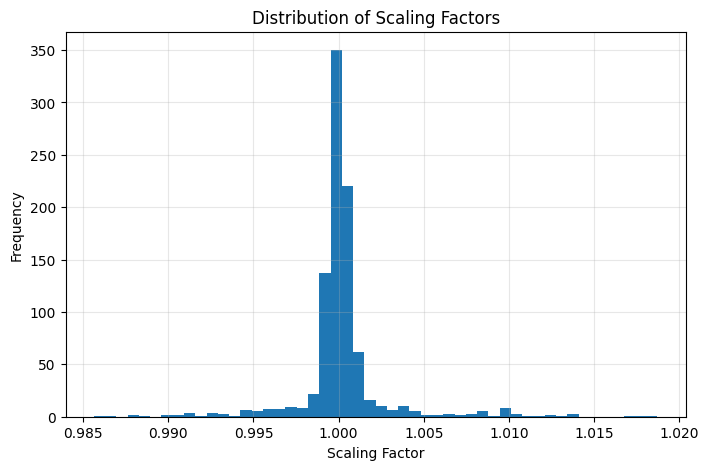

In [9]:
# SCALE DISTRIBUTION

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(daily_totals['scale'], bins=50)

plt.title("Distribution of Scaling Factors")
plt.xlabel("Scaling Factor")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

In [10]:
# 7. EVALUATE ON TEST SET ONLY

before_rmse  = np.sqrt(np.mean((df[test_mask]['Sales'] - df[test_mask]['pred'])**2))
after_rmse   = np.sqrt(np.mean((df[test_mask]['Sales'] - df[test_mask]['reconciled_pred'])**2))

before_rmspe = rmspe(df[test_mask]['Sales'], df[test_mask]['pred'])
after_rmspe  = rmspe(df[test_mask]['Sales'], df[test_mask]['reconciled_pred'])

print(f"Test set evaluation:")
print(f"  RMSE  before: {before_rmse:.2f}   after: {after_rmse:.2f}   improvement: {(1 - after_rmse/before_rmse)*100:.2f}%")
print(f"  RMSPE before: {before_rmspe:.4f}  after: {after_rmspe:.4f}  improvement: {(1 - after_rmspe/before_rmspe)*100:.2f}%")


Test set evaluation:
  RMSE  before: 157.32   after: 157.16   improvement: 0.10%
  RMSPE before: 0.0104  after: 0.0104  improvement: -0.08%


In [11]:
# 8. SAVE

df.to_csv("reconciled_predictions.csv", index=False)
print("Saved: reconciled_predictions.csv (train + test reconciled)")
print("Total rows:", len(df))


Saved: reconciled_predictions.csv (train + test reconciled)
Total rows: 844338
